In [12]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

In [5]:
data = pd.read_hdf("../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [17]:
group_sizes = [2,4,10,16,32,64,128,256,512]


In [6]:
def avg(group,group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

In [7]:
history_list_acc = []
history_list_val_acc = []
history_list_val_loss = []
history_list_loss = []


Epoch 10: saving model to training/train_avg/cp-0010.ckpt

Epoch 20: saving model to training/train_avg/cp-0020.ckpt

Epoch 30: saving model to training/train_avg/cp-0030.ckpt

Epoch 40: saving model to training/train_avg/cp-0040.ckpt

Epoch 50: saving model to training/train_avg/cp-0050.ckpt

Epoch 60: saving model to training/train_avg/cp-0060.ckpt

Epoch 70: saving model to training/train_avg/cp-0070.ckpt

Epoch 80: saving model to training/train_avg/cp-0080.ckpt

Epoch 90: saving model to training/train_avg/cp-0090.ckpt

Epoch 100: saving model to training/train_avg/cp-0100.ckpt

Epoch 110: saving model to training/train_avg/cp-0110.ckpt

Epoch 120: saving model to training/train_avg/cp-0120.ckpt

Epoch 130: saving model to training/train_avg/cp-0130.ckpt

Epoch 140: saving model to training/train_avg/cp-0140.ckpt

Epoch 150: saving model to training/train_avg/cp-0150.ckpt

Epoch 160: saving model to training/train_avg/cp-0160.ckpt

Epoch 170: saving model to training/train_avg/cp

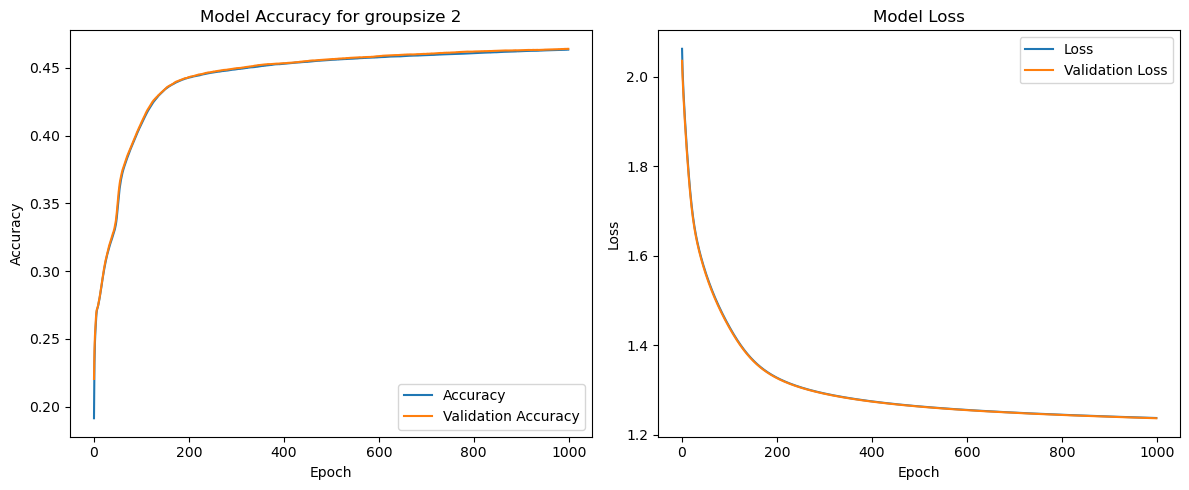

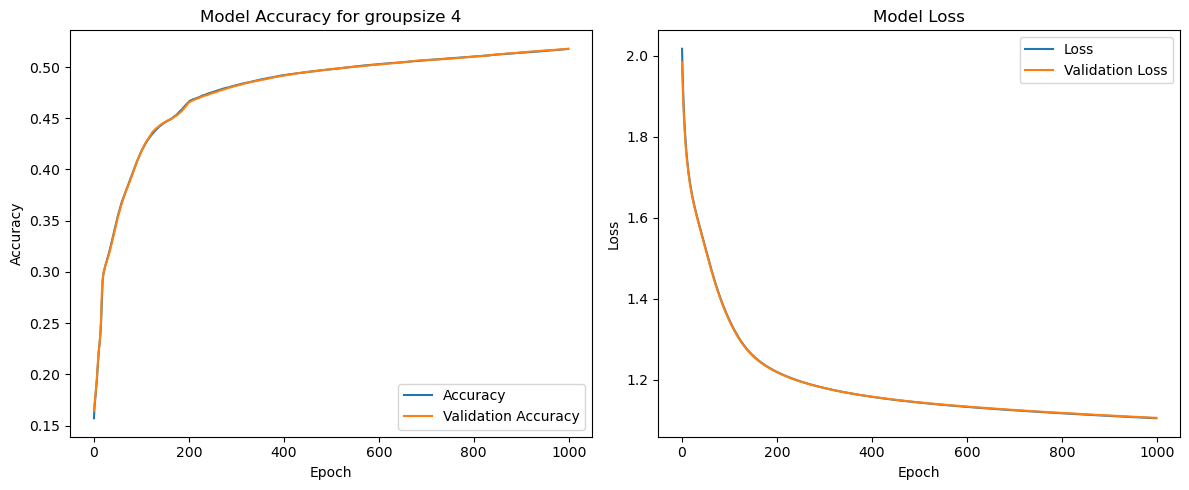

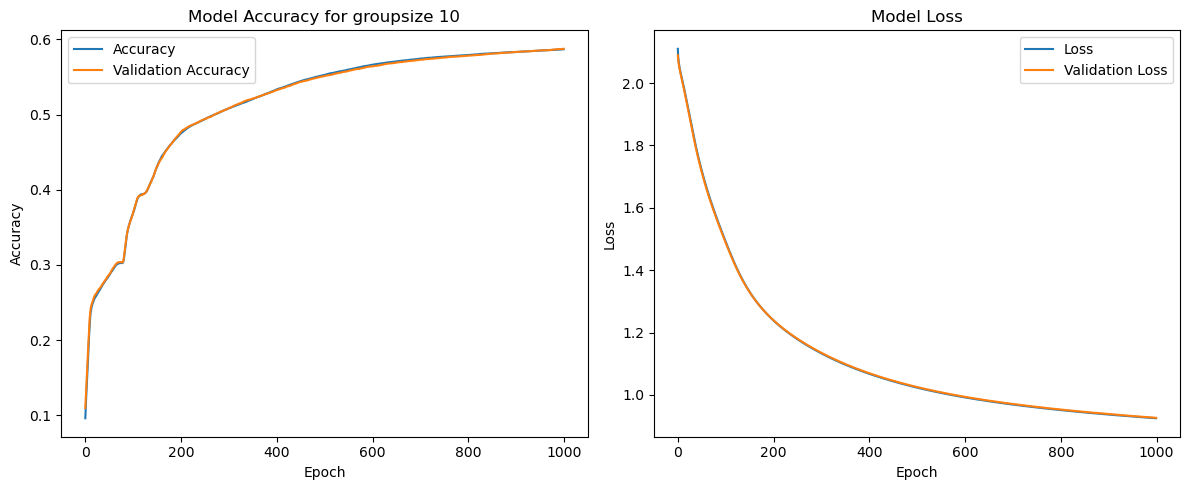

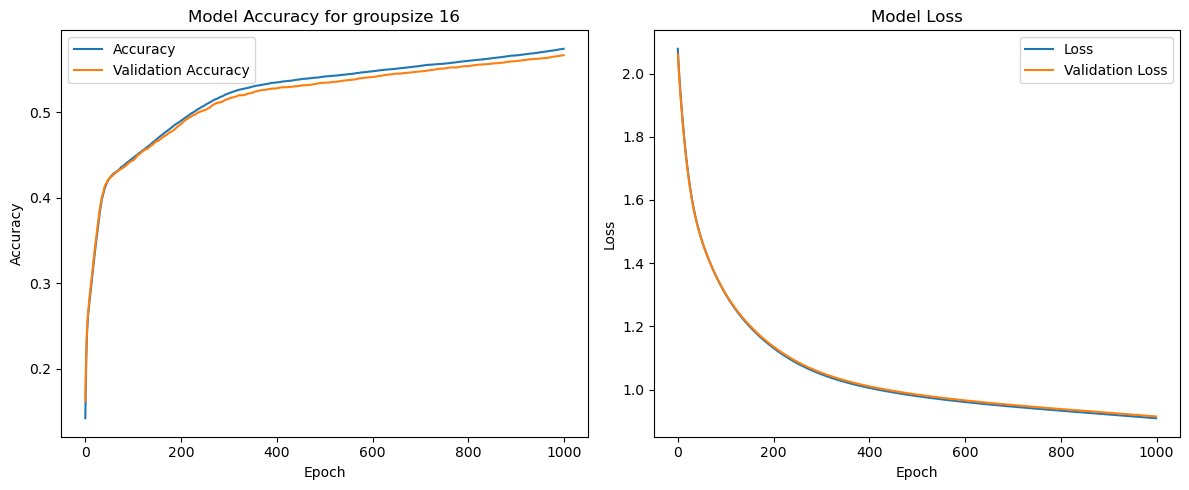

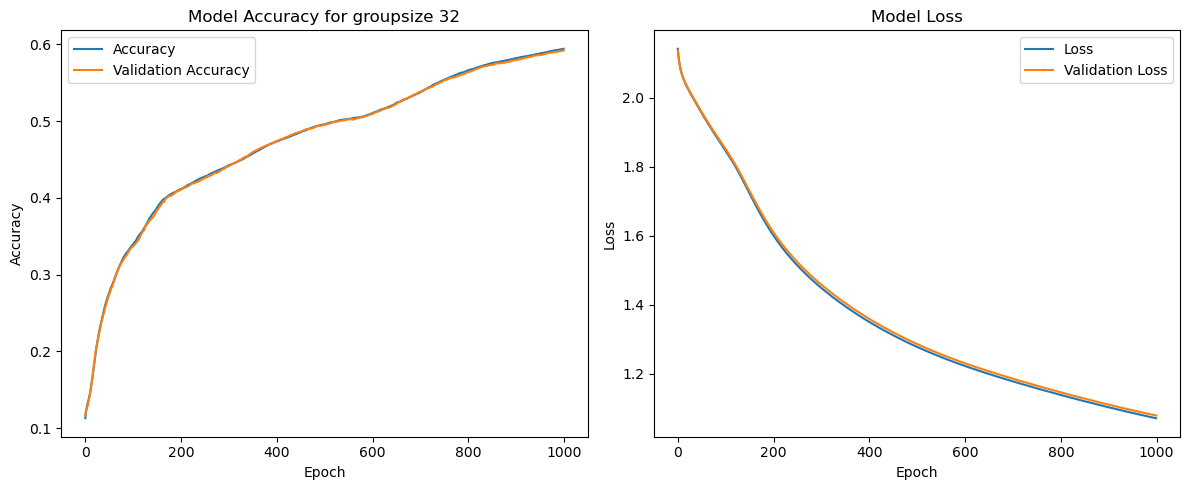

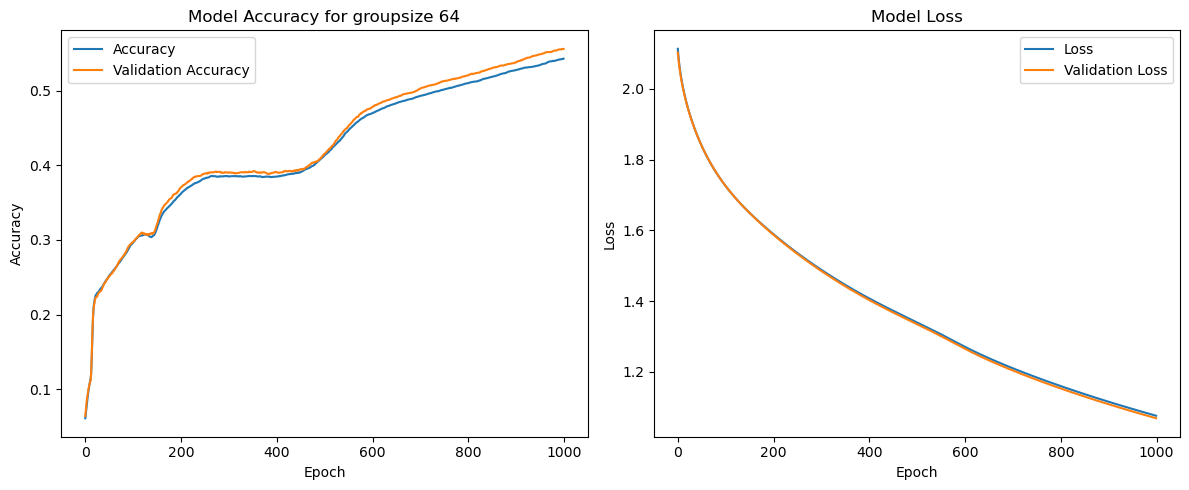

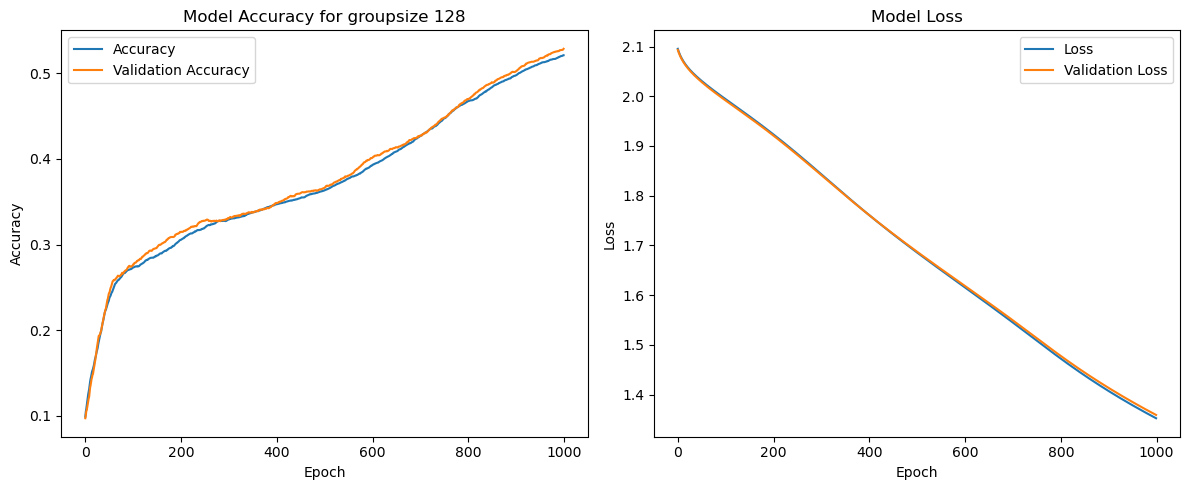

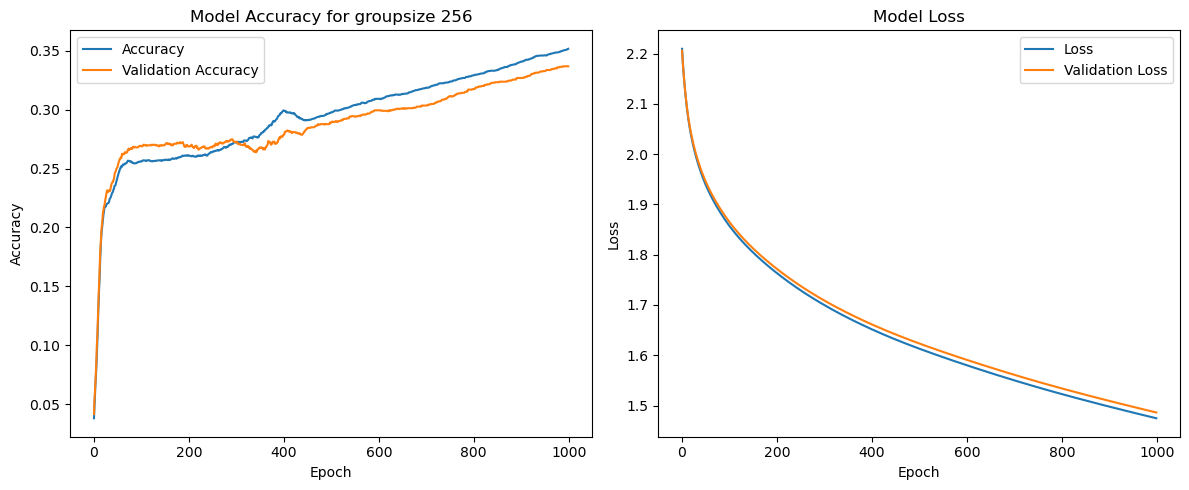

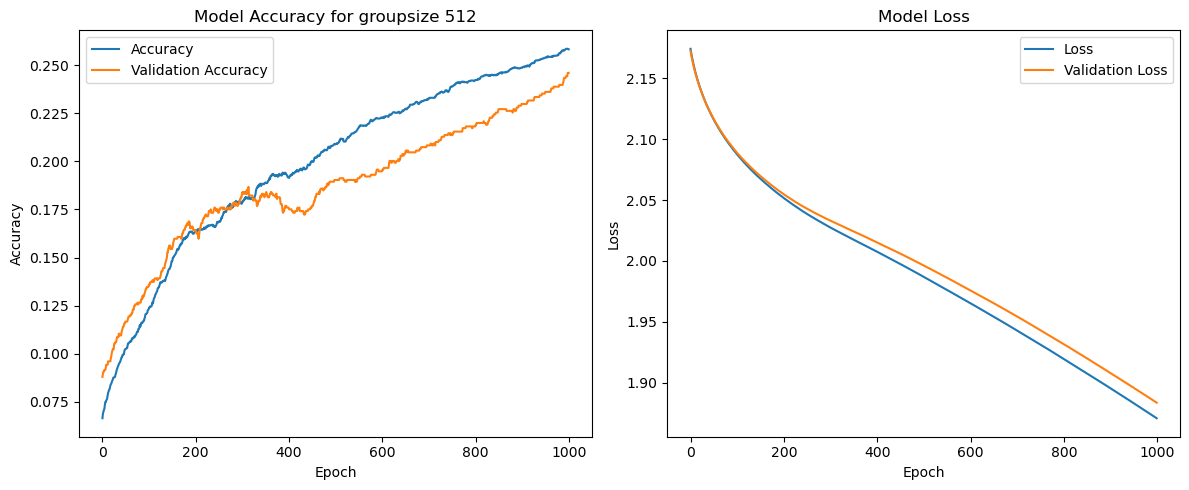

In [20]:
for group_size in group_sizes:
    averaged_df = df.groupby(['Peptide', 'Time']).apply(avg, group_size=group_size)
    averaged_df = pd.DataFrame(StandardScaler().fit_transform(averaged_df), columns=averaged_df.columns, index=averaged_df.index)

    antigen = list(averaged_df.index.get_level_values('Peptide'))
    time = list(averaged_df.index.get_level_values('Time'))

    X = np.array(averaged_df.values)
    y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
    y = to_categorical(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

    autoencoder = Sequential([
        layers.Dense(15, activation='elu'),
        layers.Dense(10, activation='softsign'),
        layers.Dense(5, activation='swish'),
        layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
        layers.Dense(5, activation='selu'), 
        layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
    ])

    autoencoder.compile(optimizer='adagrad', loss=losses.CategoricalCrossentropy(), metrics=['categorical_accuracy'])

    CHECKPOINT_PATH = "training/train_avg/cp-{epoch:04d}.ckpt"
    checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

    BATCH_SIZE = 1024
    STEPS_PER_EPOCH = X_train.shape[0] / BATCH_SIZE
    SAVE_PERIOD = 10


    training_callback = ModelCheckpoint(filepath=CHECKPOINT_PATH,
                                        save_weights_only=True,
                                        verbose=1, 
                                        save_freq=int(SAVE_PERIOD * STEPS_PER_EPOCH)
                                    )

    # autoencoder.save_weights(CHECKPOINT_PATH.format(epoch=0))

    tf.random.set_seed(42)

    hist = autoencoder.fit(X_train, y_train,
                    epochs=1000,
                    shuffle=True,
                    validation_data=(X_test, y_test),
                    callbacks=[training_callback],
                    batch_size=BATCH_SIZE,
                    verbose=0)
    
    history_list_acc.append(hist.history['categorical_accuracy'])
    history_list_val_acc.append(hist.history['val_categorical_accuracy'])
    history_list_val_loss.append(hist.history['val_loss'])
    history_list_loss.append(hist.history['loss'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot the accuracy on the first subplot
    ax1.plot(hist.history['categorical_accuracy'], label='Accuracy')
    ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'Model Accuracy for groupsize {group_size}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot the loss on the second subplot
    ax2.plot(hist.history['loss'], label='Loss')
    ax2.plot(hist.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    # Adjust the spacing between subplots
    plt.tight_layout()

Varying Batch Sizes

In [8]:
group_sizes = [10,16,32]


Epoch 10: saving model to training/train_avg/cp-0010.ckpt

Epoch 20: saving model to training/train_avg/cp-0020.ckpt

Epoch 30: saving model to training/train_avg/cp-0030.ckpt

Epoch 40: saving model to training/train_avg/cp-0040.ckpt

Epoch 50: saving model to training/train_avg/cp-0050.ckpt

Epoch 60: saving model to training/train_avg/cp-0060.ckpt

Epoch 70: saving model to training/train_avg/cp-0070.ckpt

Epoch 80: saving model to training/train_avg/cp-0080.ckpt

Epoch 90: saving model to training/train_avg/cp-0090.ckpt

Epoch 100: saving model to training/train_avg/cp-0100.ckpt

Epoch 110: saving model to training/train_avg/cp-0110.ckpt

Epoch 120: saving model to training/train_avg/cp-0120.ckpt

Epoch 130: saving model to training/train_avg/cp-0130.ckpt

Epoch 140: saving model to training/train_avg/cp-0140.ckpt

Epoch 150: saving model to training/train_avg/cp-0150.ckpt

Epoch 160: saving model to training/train_avg/cp-0160.ckpt

Epoch 170: saving model to training/train_avg/cp

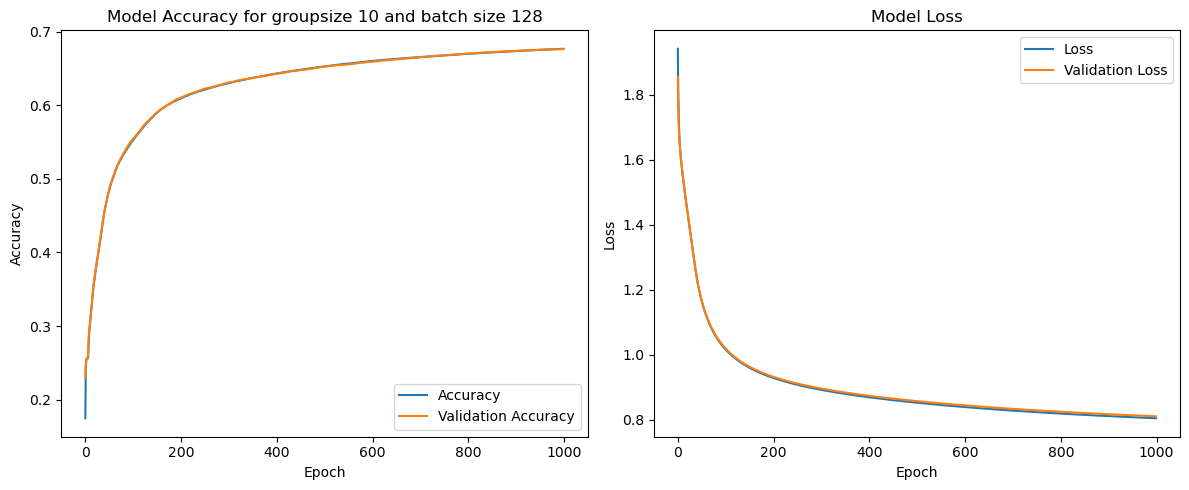

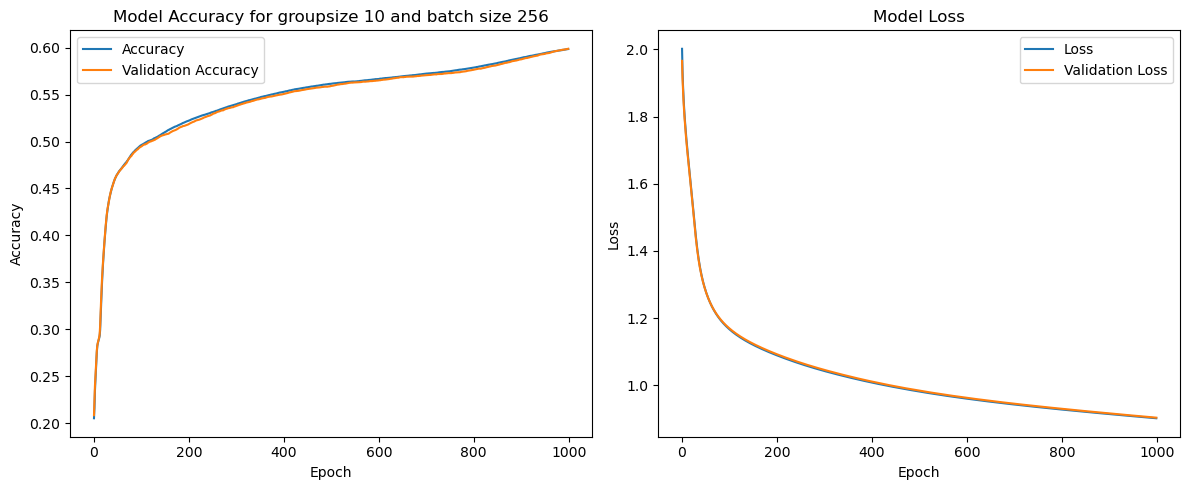

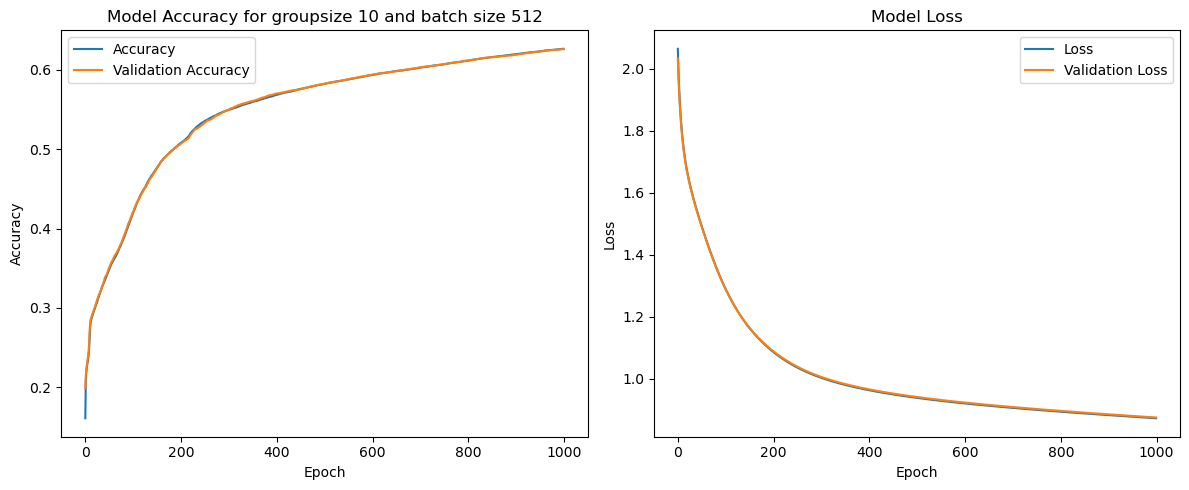

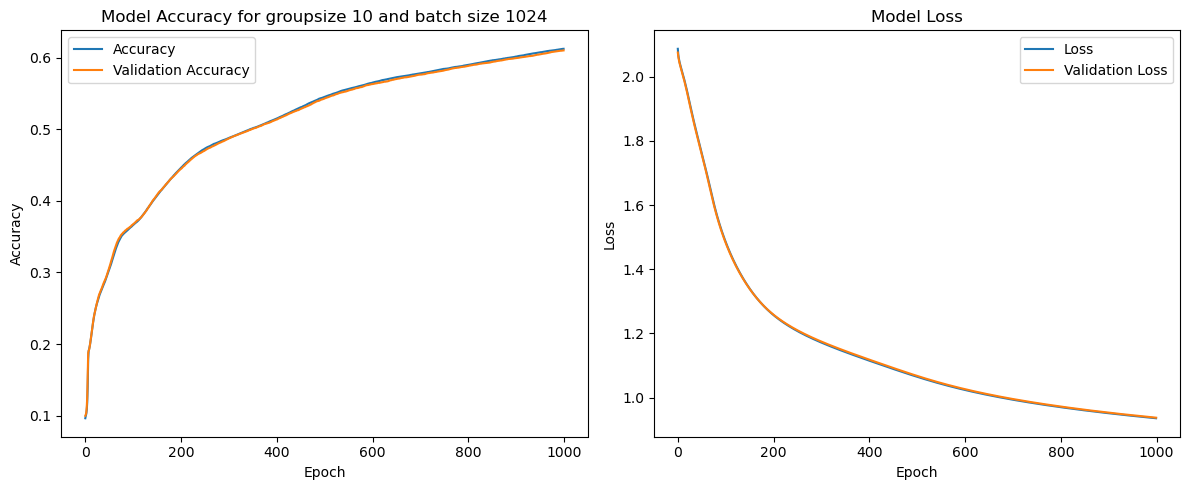

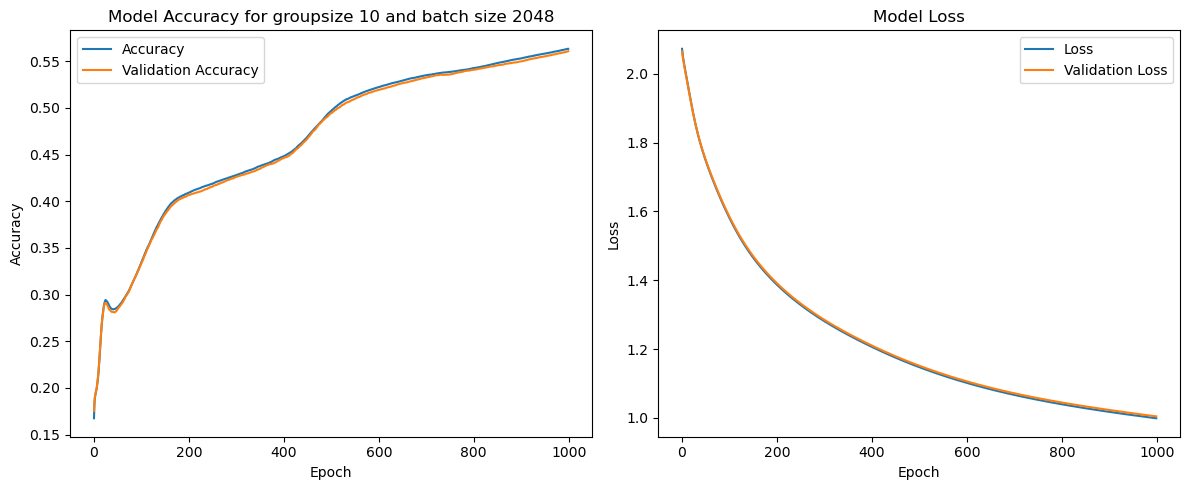

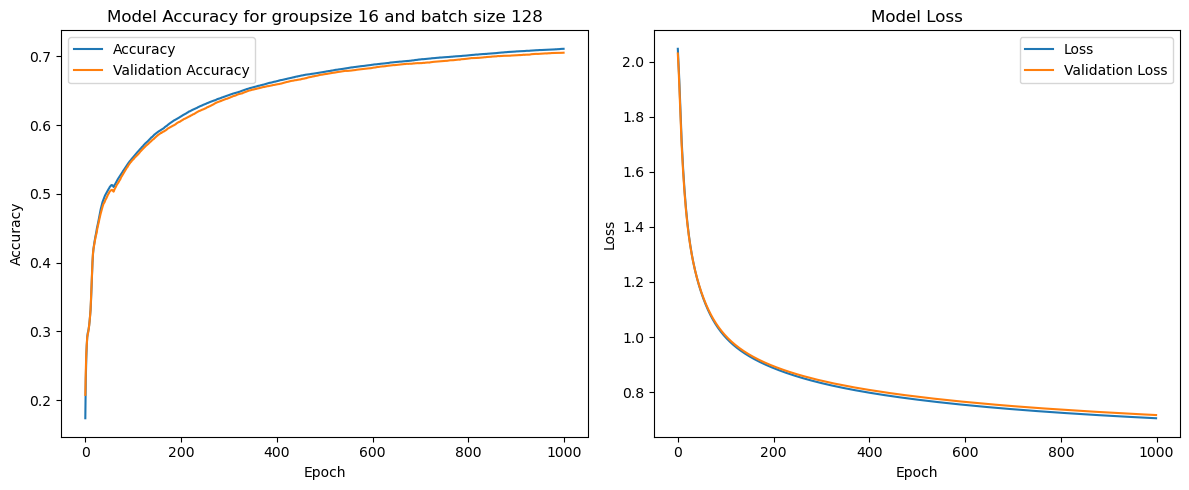

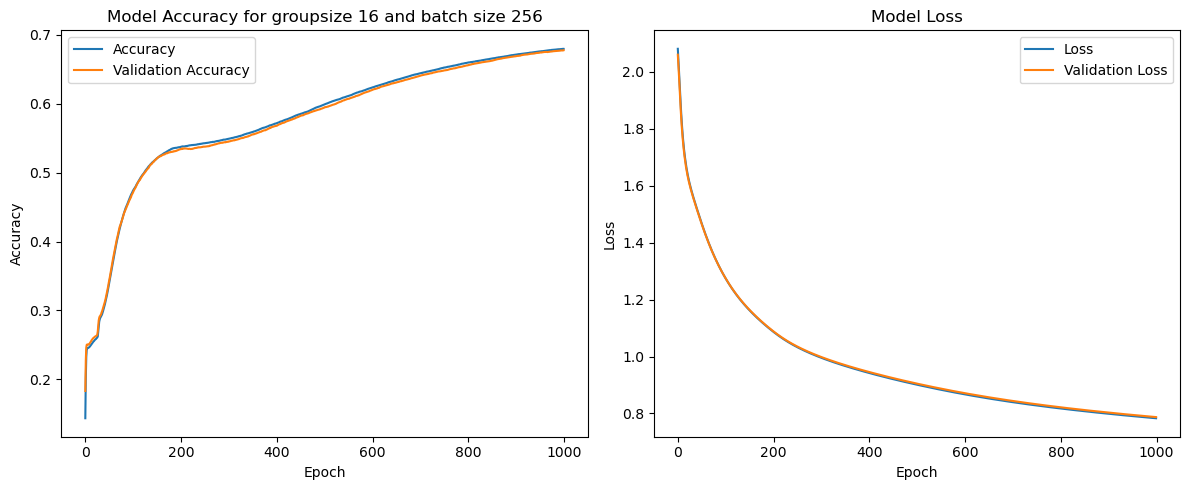

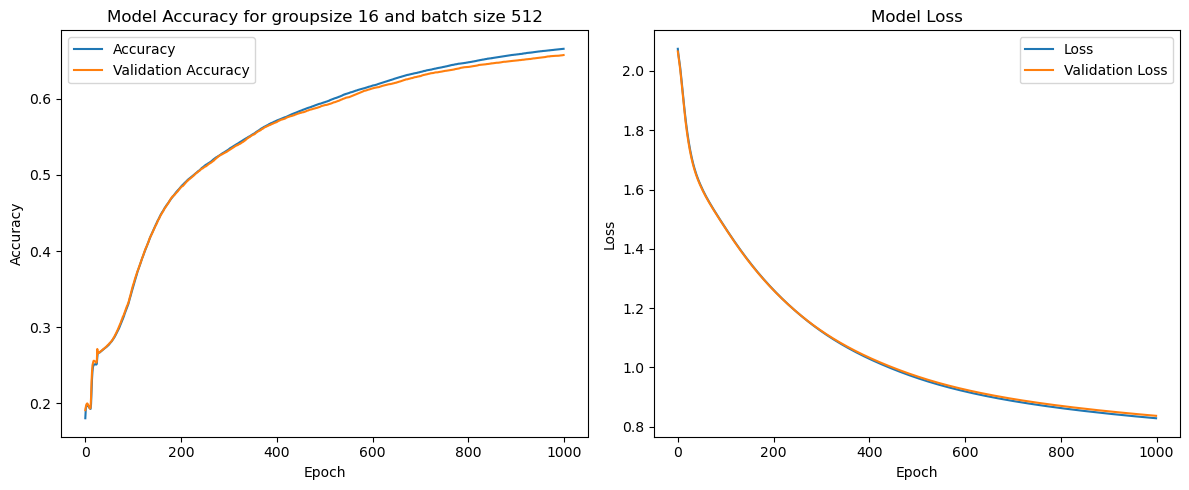

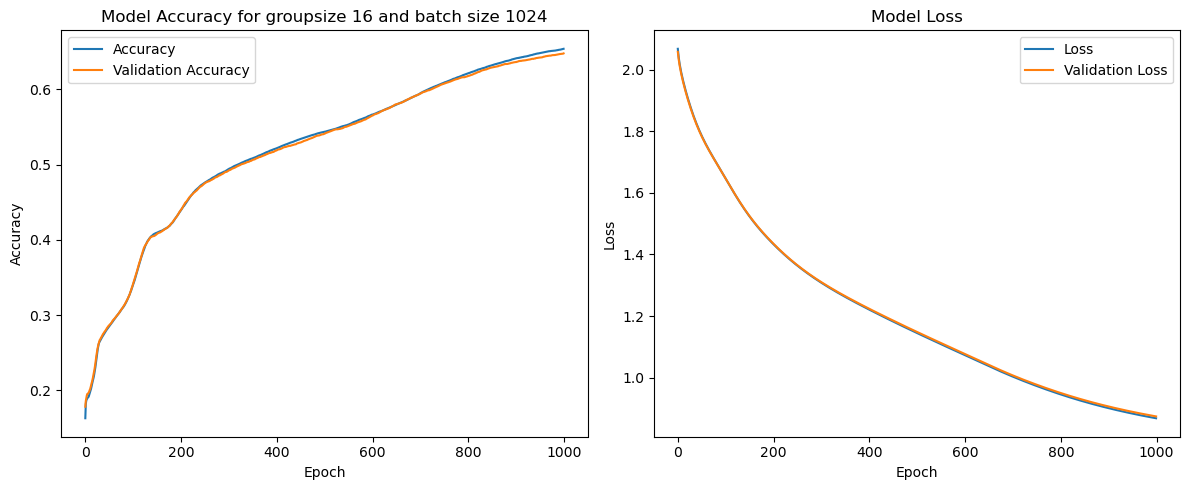

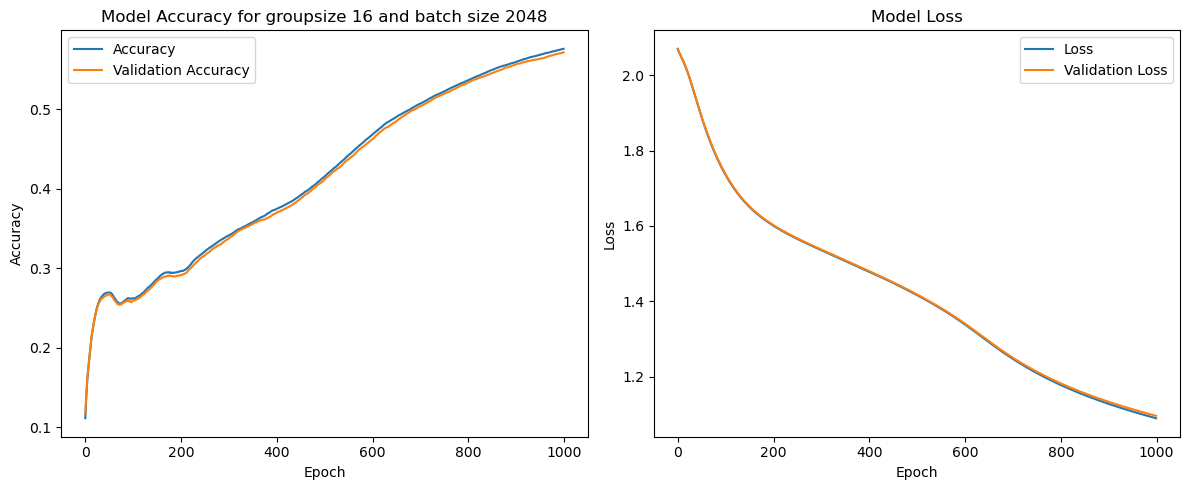

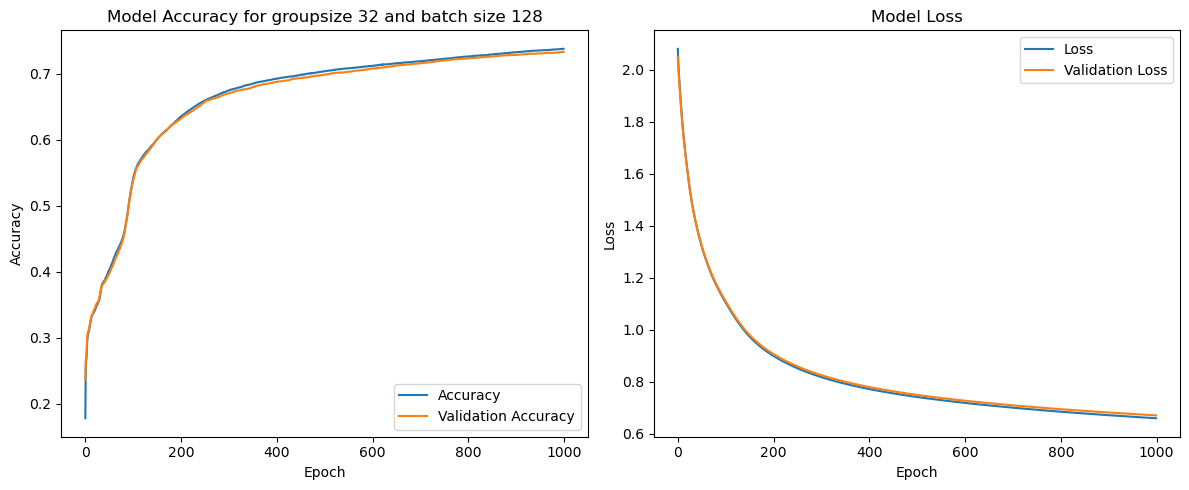

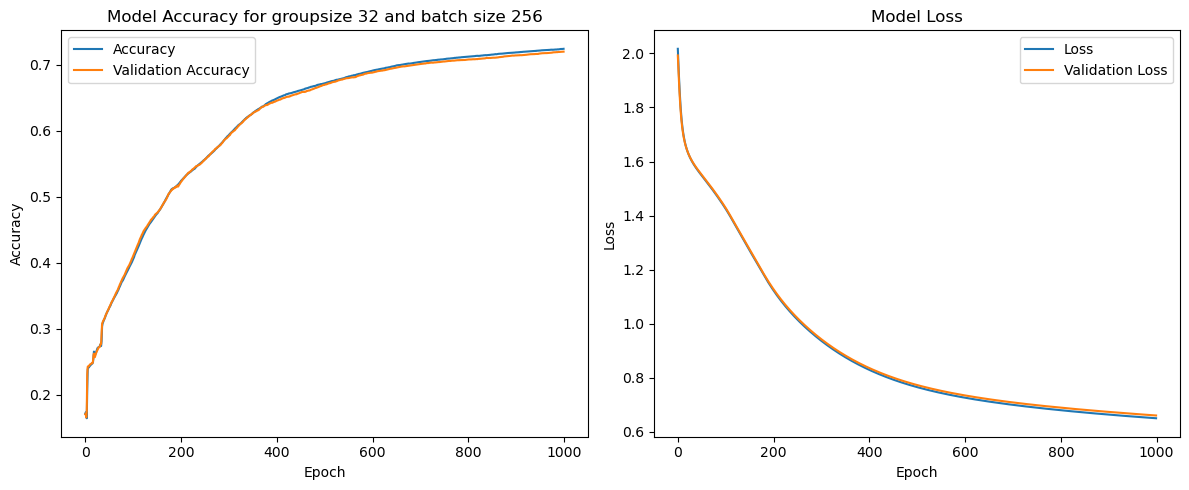

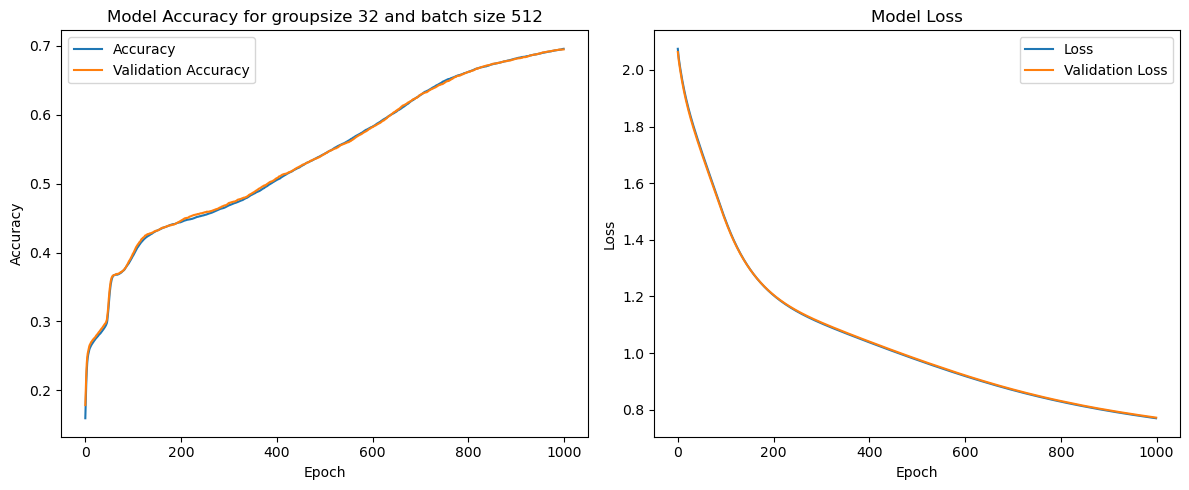

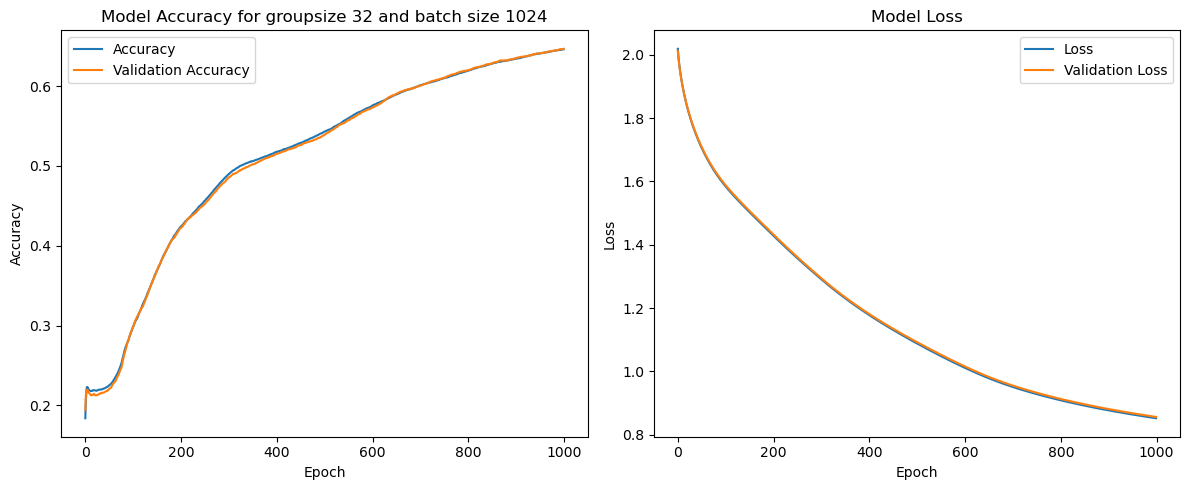

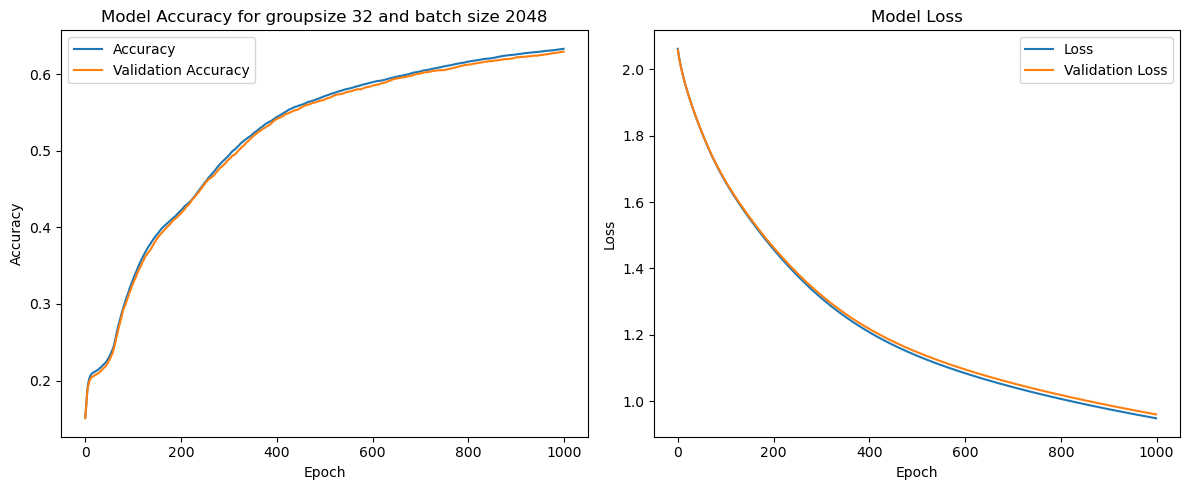

In [11]:
batch_sizes = [128, 256, 512, 1024, 2048]
for group_size in group_sizes:
    for BATCH_SIZE in batch_sizes:
        averaged_df = df.groupby(['Peptide', 'Time']).apply(avg, group_size=group_size)
        averaged_df = pd.DataFrame(StandardScaler().fit_transform(averaged_df), columns=averaged_df.columns, index=averaged_df.index)

        antigen = list(averaged_df.index.get_level_values('Peptide'))
        time = list(averaged_df.index.get_level_values('Time'))

        X = np.array(averaged_df.values)
        y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
        y = to_categorical(y)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

        autoencoder = Sequential([
            layers.Dense(15, activation='elu'),
            layers.Dense(10, activation='softsign'),
            layers.Dense(5, activation='swish'),
            layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
            layers.Dense(5, activation='selu'), 
            layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
        ])

        autoencoder.compile(optimizer='adagrad', loss=losses.CategoricalCrossentropy(), metrics=['categorical_accuracy'])

        CHECKPOINT_PATH = "training/train_avg/cp-{epoch:04d}.ckpt"
        checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

        STEPS_PER_EPOCH = X_train.shape[0] / BATCH_SIZE
        SAVE_PERIOD = 10


        training_callback = ModelCheckpoint(filepath=CHECKPOINT_PATH,
                                            save_weights_only=True,
                                            verbose=1, 
                                            save_freq=int(SAVE_PERIOD * STEPS_PER_EPOCH)
                                        )

        # autoencoder.save_weights(CHECKPOINT_PATH.format(epoch=0))

        tf.random.set_seed(42)

        hist = autoencoder.fit(X_train, y_train,
                        epochs=1000,
                        shuffle=True,
                        validation_data=(X_test, y_test),
                        callbacks=[training_callback],
                        batch_size=BATCH_SIZE,
                        verbose=0)
        
        history_list_acc.append(hist.history['categorical_accuracy'])
        history_list_val_acc.append(hist.history['val_categorical_accuracy'])
        history_list_val_loss.append(hist.history['val_loss'])
        history_list_loss.append(hist.history['loss'])

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Plot the accuracy on the first subplot
        ax1.plot(hist.history['categorical_accuracy'], label='Accuracy')
        ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
        ax1.set_title(f'Model Accuracy for groupsize {group_size} and batch size {BATCH_SIZE}')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()

        # Plot the loss on the second subplot
        ax2.plot(hist.history['loss'], label='Loss')
        ax2.plot(hist.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()

        # Adjust the spacing between subplots
        plt.tight_layout()